In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

sns.set(style="whitegrid")

df = pd.read_csv('dataset_standardized.csv')

# Удаляем текстовые колонки 
cols_to_drop =['track_id', 'artists', 'album_name', 'track_name']
df = df.drop(columns=cols_to_drop, errors='ignore')

# Создаем классы популярности
# Используем pd.cut для разбиения на 3 категории
bins =[-1, 20, 60, 100] # -1 чтобы включить треки с популярностью 0
labels =['Low', 'Medium', 'High']
df['Target'] = pd.cut(df['popularity'], bins=bins, labels=labels)

# Формируем X признаки и y классы
X = df.drop(columns=['popularity', 'Target'])
y = df['Target']

print("Данные готовы к работе!")
print(f"Размерность матрицы признаков X: {X.shape} (то есть {X.shape[1]} колонок)")
print(f"Распределение треков по классам популярности (y):\n{y.value_counts()}")

Данные готовы к работе!
Размерность матрицы признаков X: (113549, 29) (то есть 29 колонок)
Распределение треков по классам популярности (y):
Target
Medium    66159
Low       33829
High      13561
Name: count, dtype: int64


Размер обучающей выборки: (90839, 29)

Для сохранения 85% дисперсии нужно компонент: 10
Для сохранения 95% дисперсии нужно компонент: 18


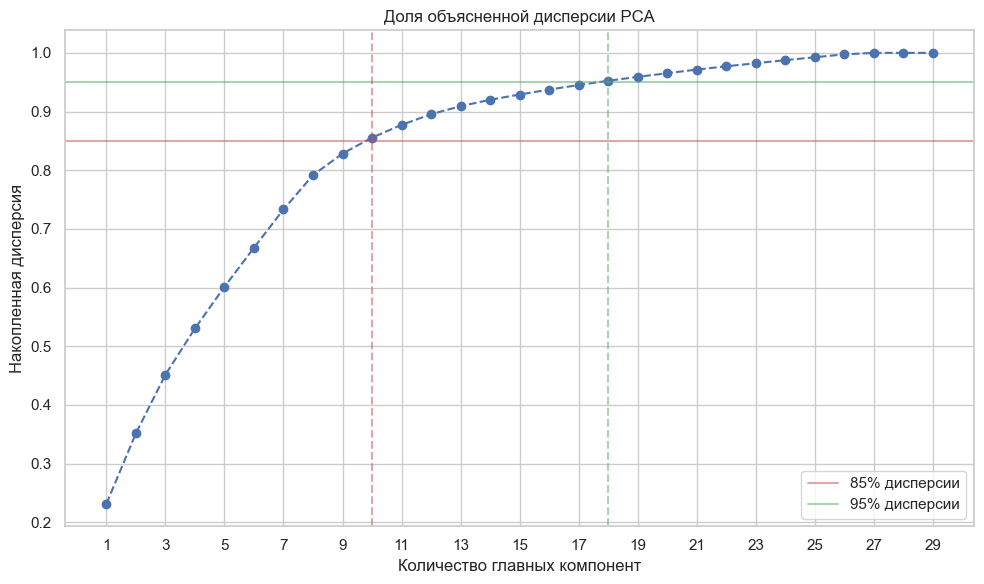

In [3]:
# Разбиваем данные на обучающую 80% и тестовую 20% 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Размер обучающей выборки: {X_train.shape}")

# Обучаем преобразование PCA на обучающей выборке без указания компонент
pca = PCA()
pca.fit(X_train)

# Считаем долю объясненной дисперсии 
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

# Находим количество компонент для 85% и 95% дисперсии
k_85 = np.argmax(cumulative_variance >= 0.85) + 1
k_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"\nДля сохранения 85% дисперсии нужно компонент: {k_85}")
print(f"Для сохранения 95% дисперсии нужно компонент: {k_95}")

# Построение графика
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')

plt.axhline(y=0.85, color='r', linestyle='-', alpha=0.5, label='85% дисперсии')
plt.axhline(y=0.95, color='g', linestyle='-', alpha=0.5, label='95% дисперсии')
plt.axvline(x=k_85, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=k_95, color='g', linestyle='--', alpha=0.5)

plt.title('Доля объясненной дисперсии PCA')
plt.xlabel('Количество главных компонент')
plt.ylabel('Накопленная дисперсия')
plt.xticks(range(1, len(cumulative_variance) + 1, 2)) # Шаг 2 для красоты
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

Исходная размерность X_train: (90839, 29)
Размерность после PCA: (90839, 10) (Сжатие почти в 3 раза!)



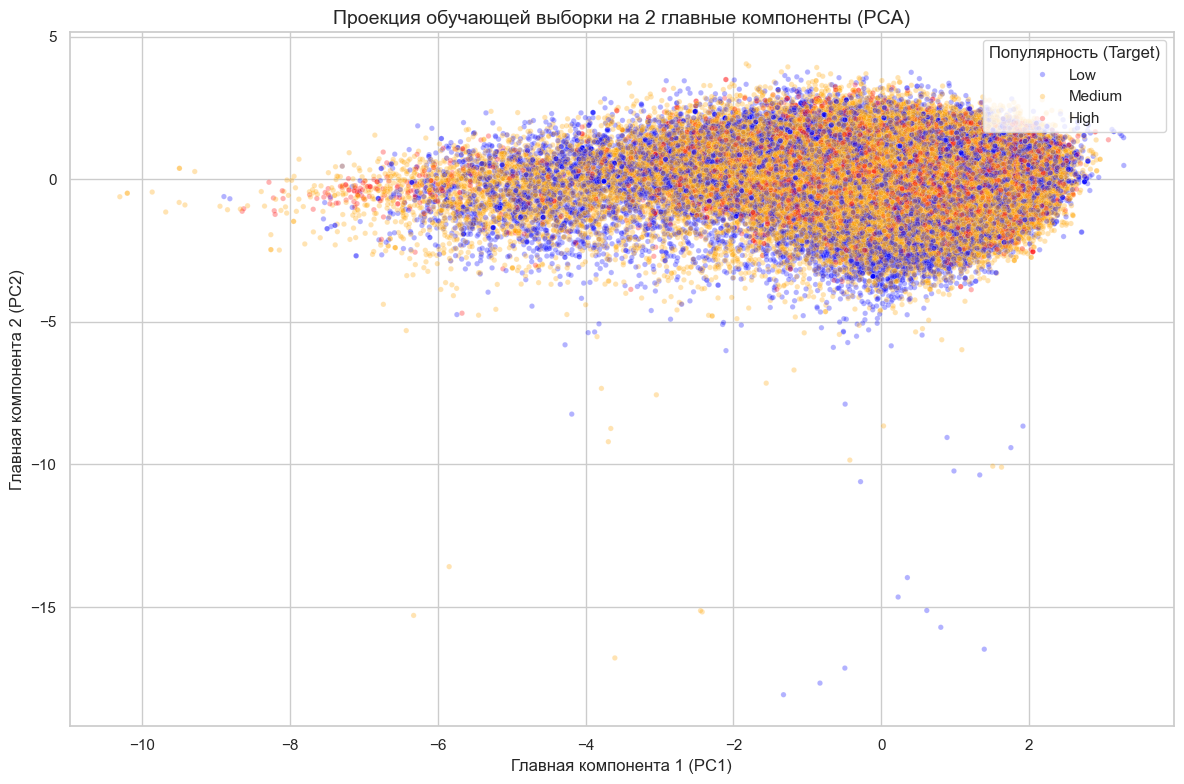

In [4]:
# Этап 1 Пункт 2 Трансформация 

# Выбираем количество компонент 
k_pca = k_85 
pca_final = PCA(n_components=k_pca)

# Обучаем и трансформируем ОБУЧАЮЩУЮ выборку
X_train_pca = pca_final.fit_transform(X_train)

# Тестовую выборку мы ТОЛЬКО трансформируем 
X_test_pca = pca_final.transform(X_test)

print(f"Исходная размерность X_train: {X_train.shape}")
print(f"Размерность после PCA: {X_train_pca.shape}")

# Этап 1 Пункт 3 Визуализация

plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=X_train_pca[:, 0],
    y=X_train_pca[:, 1],
    hue=y_train,        
    palette={'Low': 'blue', 'Medium': 'orange', 'High': 'red'},
    alpha=0.3,
    s=15
)

plt.title('Проекция обучающей выборки на 2 главные компоненты (PCA)', fontsize=14)
plt.xlabel('Главная компонента 1 (PC1)')
plt.ylabel('Главная компонента 2 (PC2)')
plt.legend(title='Популярность (Target)', loc='upper right')
plt.grid(True)
plt.tight_layout()
plt.show()

### Выводы по Этапу 1 (Трансформация PCA)

1. Анализ дисперсии: Исходное пространство состояло из 29 признаков. Алгоритм PCA показал, что для сохранения 85% дисперсии (информативности) данных достаточно всего 10 главных компонент, а для 95% — 18 компонент. Было принято решение использовать k_pca = 10, что позволило сократить размерность данных почти в 3 раза

2. Интерпретация результатов проекции: 
   * На графике проекции обучающей выборки на первые две главные компоненты (PC1 и PC2) явные изолированные кластеры разных классов не наблюдаются. 
   * Классы практически не разделяются. Сильное перекрытие. 
   * Причина: Алгоритм PCA работает без учителя. Он ищет оси максимального разброса всех данных в целом не учитывая информацию о метках классов (популярности). Первые две компоненты суммарно объясняют лишь около 35% дисперсии

Количество признаков: 29, Количество классов: 3
Максимально возможное количество компонент LDA: 2



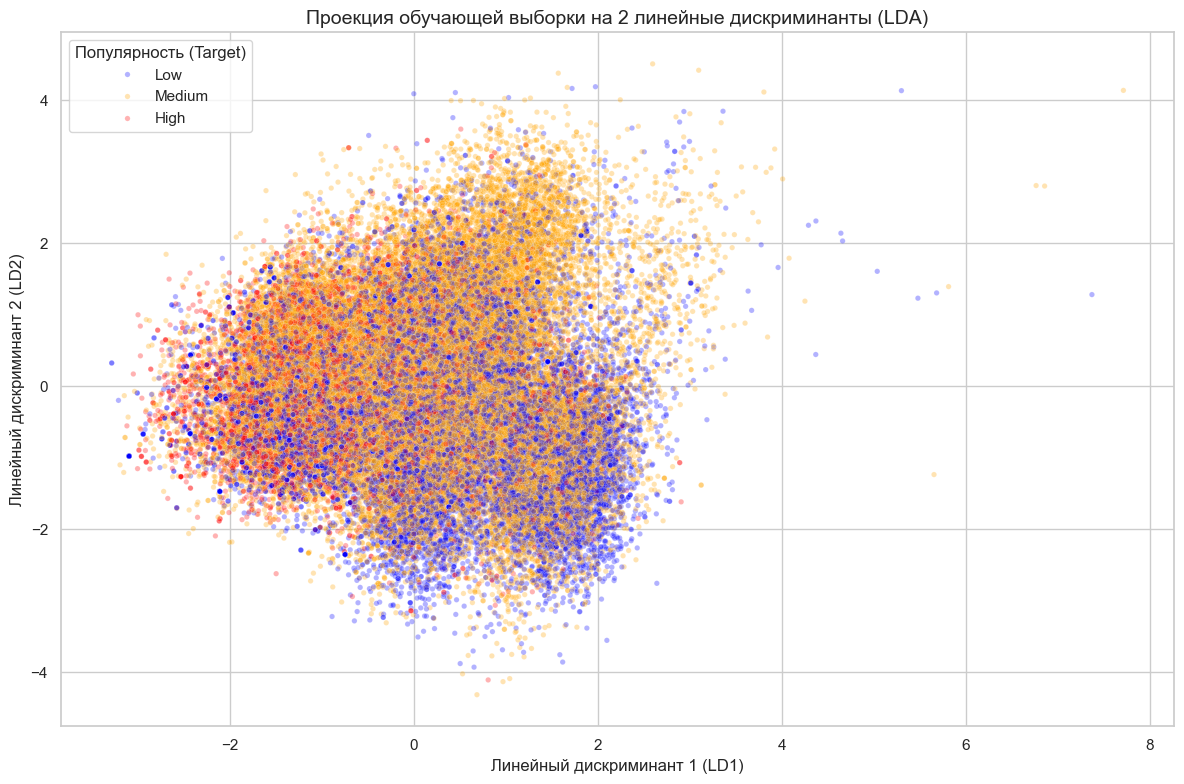

In [5]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Этап 2, Пункт 1 Обучение и трансформация (LDA) 

# Определяем максимальное количество компонент
n_classes = len(y_train.unique())
n_features = X_train.shape[1]
max_lda_components = min(n_features, n_classes - 1)
print(f"Количество признаков: {n_features}, Количество классов: {n_classes}")
print(f"Максимально возможное количество компонент LDA: {max_lda_components}\n")

# Выбираем количество компонент (k_lda)
k_lda = max_lda_components 
lda = LinearDiscriminantAnalysis(n_components=k_lda)

# Обучаем и трансформируем ОБУЧАЮЩУЮ выборку
# ОТЛИЧИЕ ОТ PCA: Мы передаем y_train, так как метод работает с учителем
X_train_lda = lda.fit_transform(X_train, y_train)

# Тестовую выборку только трансформируем
X_test_lda = lda.transform(X_test)


# Этап 2 Пункт 2 Визуализация (LDA) 

plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=X_train_lda[:, 0],
    y=X_train_lda[:, 1], 
    hue=y_train,
    palette={'Low': 'blue', 'Medium': 'orange', 'High': 'red'},
    alpha=0.3,
    s=15
)

plt.title('Проекция обучающей выборки на 2 линейные дискриминанты (LDA)', fontsize=14)
plt.xlabel('Линейный дискриминант 1 (LD1)')
plt.ylabel('Линейный дискриминант 2 (LD2)')
plt.legend(title='Популярность (Target)', loc='best')
plt.grid(True)
plt.tight_layout()
plt.show()

### Выводы по Этапу 2 Трансформация LDA и сравнение с PCA

1. Максимальное количество линейных дискриминант ограничено формулой min(n_features, n_classes - 1). Для 3 классов (Low, Medium, High) максимально возможное количество компонент равно 2. Именно это значение k_lda = 2 было использовано для трансформации, сжав признаковое пространство с 29 до 2 осей.

2. Сравнение визуализаций:
   * В отличие от PCA, где классы образовывали перемешанное облако, на графике LDA заметна тенденция к кластеризации и смещению центров масс разных классов. 
   * Вывод: Пространство LDA лучше разделяет классы, так как этот алгоритм обучался с учителем учитывая целевую переменную y и целенаправленно максимизировал расстояние между средними значениями классов, минимизируя разброс внутри самих классов. 

In [6]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
import time

# Этап 3 Сравнение качества классификации 

# Инициализируем 3 одинаковые модели KNN
# n_neighbors=5 будем смотреть на 5 ближайших треков, чтобы определить класс
knn_orig = KNeighborsClassifier(n_neighbors=5)
knn_pca = KNeighborsClassifier(n_neighbors=5)
knn_lda = KNeighborsClassifier(n_neighbors=5)

print("Начинаем обучение и тестирование моделей...\n")

# Исходное пространство (29 признаков)
start_time = time.time()
knn_orig.fit(X_train, y_train)
y_pred_orig = knn_orig.predict(X_test)
acc_orig = accuracy_score(y_test, y_pred_orig)
time_orig = time.time() - start_time
print(f"1. Исходное пространство (29 признаков):")
print(f"   Точность (Accuracy): {acc_orig:.4f}")
print(f"   Время работы: {time_orig:.2f} сек.\n")

# Пространство PCA (10 признаков)
start_time = time.time()
knn_pca.fit(X_train_pca, y_train)
y_pred_pca = knn_pca.predict(X_test_pca)
acc_pca = accuracy_score(y_test, y_pred_pca)
time_pca = time.time() - start_time
print(f"2. Пространство PCA (10 признаков):")
print(f"   Точность (Accuracy): {acc_pca:.4f}")
print(f"   Время работы: {time_pca:.2f} сек.\n")

# Пространство LDA (2 признака)
start_time = time.time()
knn_lda.fit(X_train_lda, y_train)
y_pred_lda = knn_lda.predict(X_test_lda)
acc_lda = accuracy_score(y_test, y_pred_lda)
time_lda = time.time() - start_time
print(f"3. Пространство LDA (2 признака):")
print(f"   Точность (Accuracy): {acc_lda:.4f}")
print(f"   Время работы: {time_lda:.2f} сек.\n")

Начинаем обучение и тестирование моделей...

1. Исходное пространство (29 признаков):
   Точность (Accuracy): 0.6401
   Время работы: 3.39 сек.

2. Пространство PCA (10 признаков):
   Точность (Accuracy): 0.6425
   Время работы: 2.09 сек.

3. Пространство LDA (2 признака):
   Точность (Accuracy): 0.5850
   Время работы: 0.14 сек.



### Выводы по Этапу 3 (Сравнение качества классификации алгоритмом KNN)

1. Сохранение и повышение качества: Трансформация в пространство меньшей размерности (PCA) не только сохранила, но и незначительно повысила качество классификации (с 0.6401 до 0.6425), при этом сократив время предсказания примерно на 40%. 
2. Анализ LDA: Трансформация LDA снизила размерность до 2 признаков. Скорость работы алгоритма выросла с 3.39 до 0.14 сек. Из-за потери значительной части дисперсии данных точность упала до 0.5850. 
3. Эффект для метрических моделей: Эффект улучшения качества от понижения размерности наиболее ярко заметен именно на метрических моделях, таких как k-NN, он страдает от проклятия размерности: в многомерном 29D-пространстве расстояния между точками искажаются шумовыми неинформативными признаками. PCA удалил коллинеарность и шум, оставив 85% самой важной дисперсии в 10 ортогональных осях, что позволило функции евклидова расстояния работать гораздо эффективнее.

Запускаем t-SNE. Это займет пару минут...
Считаем t-SNE (perplexity = 5)...
Считаем t-SNE (perplexity = 30)...
Считаем t-SNE (perplexity = 50)...


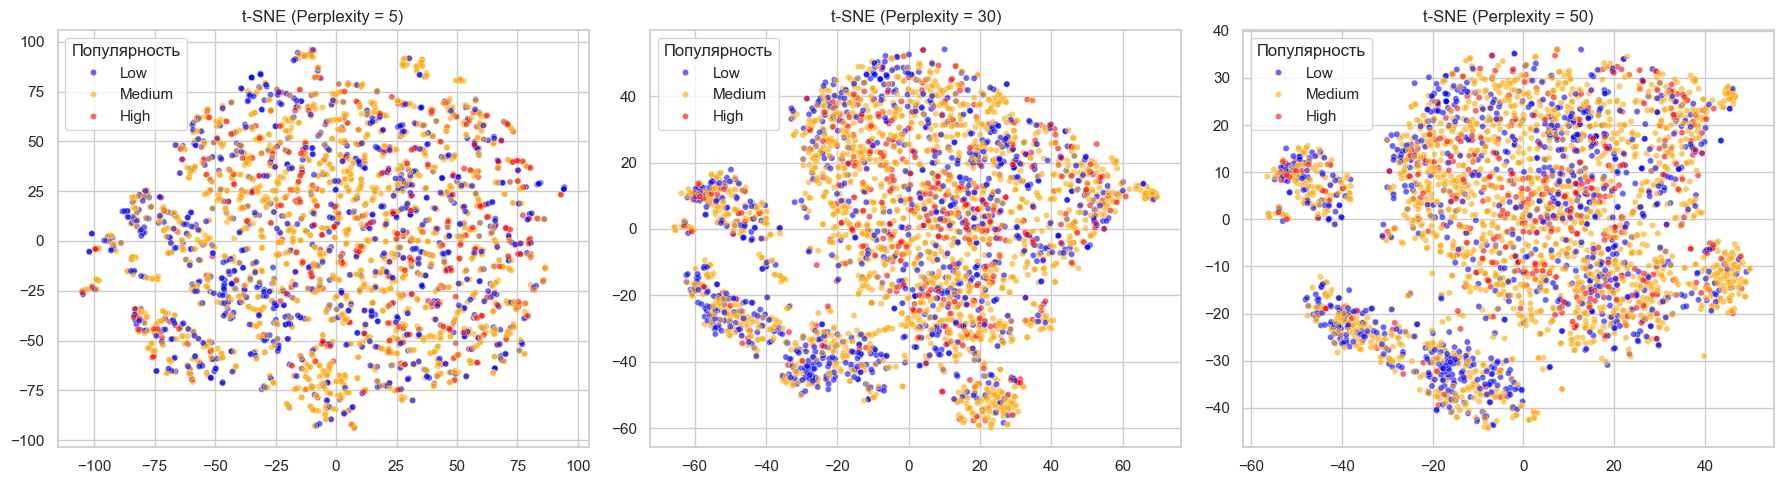

Готово!


In [8]:
from sklearn.manifold import TSNE

# Этап 4: Нелинейная трансформация t-SNE 

print("Запускаем t-SNE...")

# 1. Делаем случайную подвыборку (чтобы не сжечь процессор)
# Берем 3000 случайных точек из обучающей выборки
np.random.seed(42)
sample_indices = np.random.choice(X_train.shape[0], size=3000, replace=False)

X_sample = X_train.iloc[sample_indices]
y_sample = y_train.iloc[sample_indices]

# 2. Список значений perplexity из задания
perplexities = [5, 30, 50]

plt.figure(figsize=(18, 5))

# 3. Строим t-SNE для каждого значения perplexity
for i, perp in enumerate(perplexities):
    print(f"Считаем t-SNE (perplexity = {perp})...")
    
    # Инициализация и обучение t-SNE
    # n_components=2 (проецируем на плоскость)
    tsne = TSNE(n_components=2, perplexity=perp, random_state=42, n_jobs=-1)
    X_tsne = tsne.fit_transform(X_sample)
    
    # Отрисовка
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(
        x=X_tsne[:, 0], 
        y=X_tsne[:, 1], 
        hue=y_sample, 
        palette={'Low': 'blue', 'Medium': 'orange', 'High': 'red'},
        alpha=0.6,
        s=20
    )
    plt.title(f't-SNE (Perplexity = {perp})')
    plt.legend(title='Популярность', loc='best')

plt.tight_layout()
plt.show()
print("Готово!")

### Выводы по Этапу 4 (Нелинейная трансформация t-SNE)

1. Влияние гиперпараметра perplexity:
   * При малых значениях perplexity = 5 алгоритм фокусируется исключительно на ближайшем локальном окружении точек. Визуализация получается фрагментированной, состоящей из множества мелких осколков, глобальная структура данных не прослеживается.
   * При увеличении значения perplexity = 30 и 50 алгоритм начинает учитывать более широкие окрестности. Осколки сливаются в четко очерченные кластеры. 

2. Сравнение с PCA и LDA:
   * PCA линейный метод без учителя спроецировал данные в единое бесформенное облако, так как просто искал оси максимальной дисперсии.
   * LDA линейный метод с учителем искусственно растянул облако, пытаясь максимально раздвинуть центры масс трех классов популярности.
   * t-SNE нелинейный метод оказался лучшим инструментом для визуализации локальной структуры. Он показал наши данные состоят из множества нелинейных сгустков кластеров, которые, вероятно, соответствуют различным поджанрам музыки. 

### Этап 5: Общие выводы по лабораторной работе

В ходе работы были изучены и применены методы снижения размерности данных PCA, LDA и нелинейной визуализации t-SNE.

1. Трансформация PCA: Метод главных компонент показал высокую эффективность для очистки данных от шума и избыточности. Снижение размерности с 29 до 10 признаков при сохранении 85% дисперсии позволило не только ускорить работу метрического алгоритма k-NN на 40%, но и повысить его точность с 0.6401 до 0.6425, избавив алгоритм от проклятия размерности.
2. Трансформация LDA: Линейный дискриминантный анализ продемонстрировал способность радикально сжимать пространство до 2 осей с учетом информации о классах. Это привело к ускорению классификации в 25 раз, однако сжатие вызвало небольшую потерю точности до 0.5850, так как классы имеют сильное нелинейное перекрытие.
3. Разница в подходах: PCA выгодно применять как этап препроцессинга для избавления от коллинеарности и шума без потери общей информативности. LDA лучше подходит в качестве шага перед линейной классификацией. t-SNE стоит использовать исключительно для исследовательского визуального анализа, так как метод не сохраняет глобальные расстояния и не формирует функций для трансформации новых данных.